# ISLP — Applied Question 13
## Classification with the `Weekly` Dataset

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 14, 2026

This notebook answers Applied Question 13 on pages 196–197 of *An Introduction to Statistical Learning with Applications in Python*.  It analyzes the `Weekly` stock-market dataset using logistic regression, linear discriminant analysis (LDA), quadratic discriminant analysis (QDA), K-nearest neighbors (KNN), and naive Bayes.

## Setup

In [1]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display
from ISLP import load_data
from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

Weekly = load_data("Weekly")
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


## (a) Numerical and graphical summaries

The first step is to examine the dataset's dimensions, variable types, descriptive statistics, response distribution, correlations, and prominent graphical patterns.

In [2]:
print(f"Dataset dimensions: {Weekly.shape[0]:,} observations × {Weekly.shape[1]} variables")
print("\nVariable types:")
print(Weekly.dtypes)

print("\nNumerical summary:")
display(Weekly.describe().round(4))

direction_summary = pd.DataFrame({
    "Count": Weekly["Direction"].value_counts(),
    "Percentage": Weekly["Direction"].value_counts(normalize=True).mul(100).round(2)
}).reindex(["Down", "Up"])
display(direction_summary)

Dataset dimensions: 1,089 observations × 9 variables

Variable types:
Year            int64
Lag1          float64
Lag2          float64
Lag3          float64
Lag4          float64
Lag5          float64
Volume        float64
Today         float64
Direction    category
dtype: object

Numerical summary:


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000
mean,2000.0487,0.1506,0.1511,0.1472,0.1458,0.1399,1.5746,0.1499
std,6.0332,2.3570,2.3573,2.3605,2.3603,2.3613,1.6866,2.3569
min,1990.0000,-18.1950,-18.1950,-18.1950,-18.1950,-18.1950,0.0875,-18.1950
25%,1995.0000,-1.1540,-1.1540,-1.1580,-1.1580,-1.1660,0.3320,-1.1540
50%,2000.0000,0.2410,0.2410,0.2410,0.2380,0.2340,1.0027,0.2410
75%,2005.0000,1.4050,1.4090,1.4090,1.4090,1.4050,2.0537,1.4050
max,2010.0000,12.0260,12.0260,12.0260,12.0260,12.0260,9.3282,12.0260


,Count,Percentage
Direction,,
Down,484,44.44
Up,605,55.56


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000,-0.032,-0.033,-0.030,-0.031,-0.031,0.842,-0.032
Lag1,-0.032,1.000,-0.075,0.059,-0.071,-0.008,-0.065,-0.075
Lag2,-0.033,-0.075,1.000,-0.076,0.058,-0.072,-0.086,0.059
Lag3,-0.030,0.059,-0.076,1.000,-0.075,0.061,-0.069,-0.071
Lag4,-0.031,-0.071,0.058,-0.075,1.000,-0.076,-0.061,-0.008
Lag5,-0.031,-0.008,-0.072,0.061,-0.076,1.000,-0.059,0.011
Volume,0.842,-0.065,-0.086,-0.069,-0.061,-0.059,1.000,-0.033
Today,-0.032,-0.075,0.059,-0.071,-0.008,0.011,-0.033,1.000


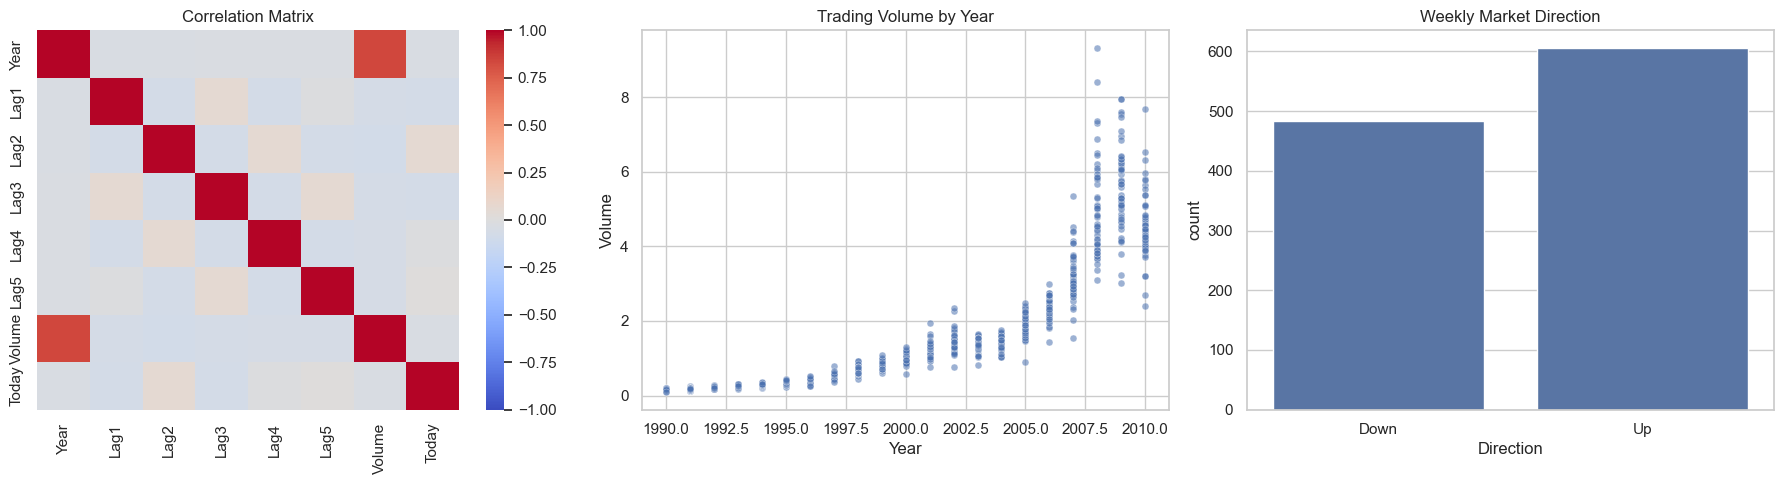

In [3]:
numeric_variables = ["Year", "Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]
correlations = Weekly[numeric_variables].corr()
display(correlations.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(correlations, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlation Matrix")

sns.scatterplot(data=Weekly, x="Year", y="Volume", alpha=0.55, s=25, ax=axes[1])
axes[1].set_title("Trading Volume by Year")

sns.countplot(data=Weekly, x="Direction", order=["Down", "Up"], ax=axes[2])
axes[2].set_title("Weekly Market Direction")

plt.tight_layout()
plt.show()

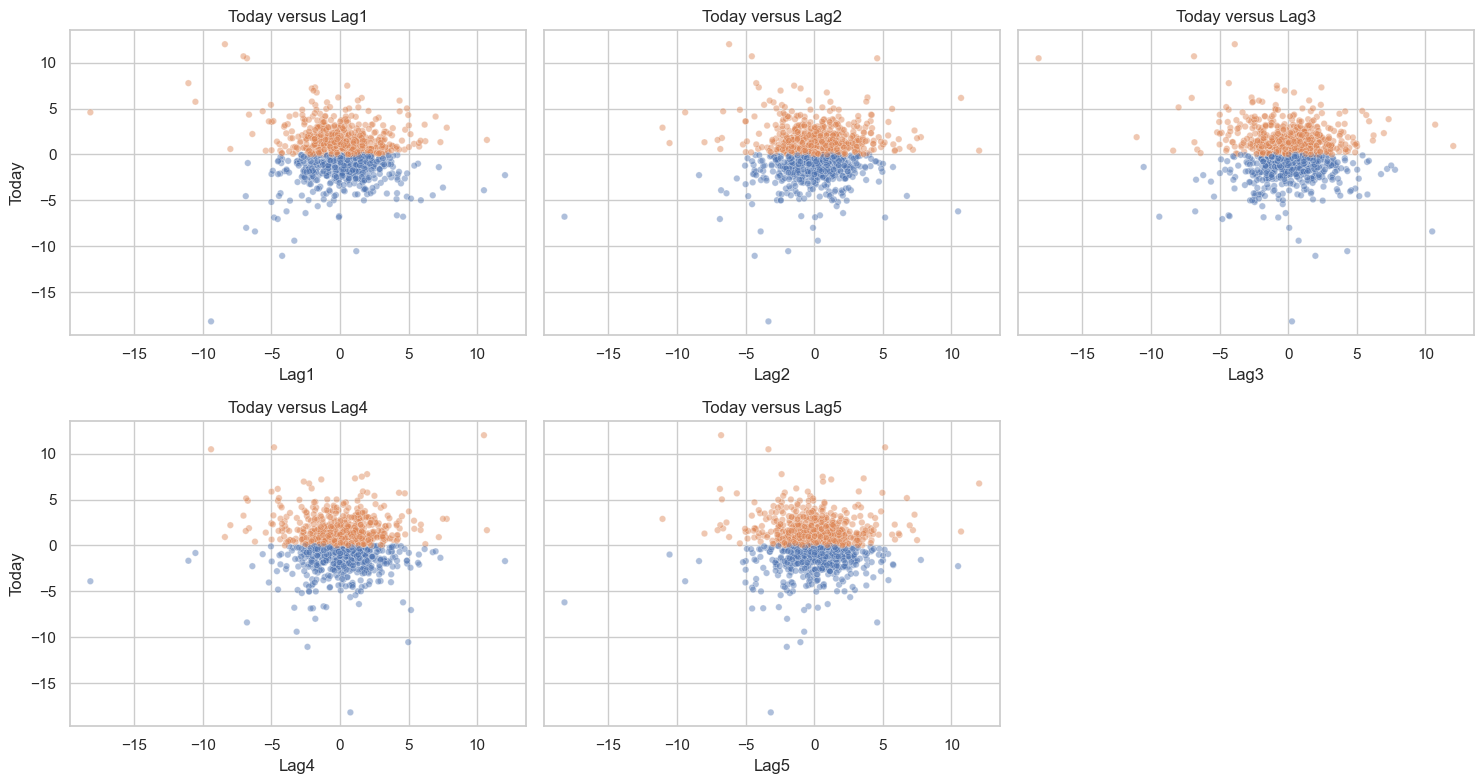

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, lag in zip(axes.flat, ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5"]):
    sns.scatterplot(data=Weekly, x=lag, y="Today", hue="Direction",
                    hue_order=["Down", "Up"], alpha=0.45, s=22, ax=ax, legend=False)
    ax.set_title(f"Today versus {lag}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

The dataset contains 1,089 weekly observations covering 1990–2010.  There are 605 upward weeks (55.56%) and 484 downward weeks (44.44%), indicating a modest imbalance toward the `Up` class.

The most noticeable relationship in the data is between `Year` and `Volume` ($r=0.842$).  This strong positive correlation shows that average weekly trading volume tended to increase as the years progressed.  The relationships among the weekly market returns, however, are much weaker.  Returns from previous weeks (`Lag1` through `Lag5`) have very little correlation with one another or with the current week's return (`Today`).  For example, the correlation between `Lag2` and `Today` is only about 0.059, which is close to zero.  In practical terms, knowing the market return from two weeks earlier tells us very little about the return in the current week.  Overall, these correlations suggest that past weekly returns alone do not provide a strong linear signal for predicting current weekly market performance.


## (b) Full-sample logistic regression

In [5]:
predictors = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]
y_full = (Weekly["Direction"] == "Up").astype(int)
X_full = sm.add_constant(Weekly[predictors])

full_logistic = sm.GLM(y_full, X_full, family=sm.families.Binomial()).fit()
print(full_logistic.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Fri, 14 Aug 2026   Deviance:                       1486.4
Time:                        10:11:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.0

In [6]:
coefficient_table = pd.DataFrame({
    "Coefficient": full_logistic.params,
    "Std. Error": full_logistic.bse,
    "z": full_logistic.tvalues,
    "p-value": full_logistic.pvalues,
    "Odds Ratio": np.exp(full_logistic.params)
})
display(coefficient_table.round(4))

,Coefficient,Std. Error,z,p-value,Odds Ratio
const,0.2669,0.0859,3.1056,0.0019,1.3059
Lag1,-0.0413,0.0264,-1.5626,0.1181,0.9596
Lag2,0.0584,0.0269,2.1754,0.0296,1.0602
Lag3,-0.0161,0.0267,-0.6024,0.5469,0.9841
Lag4,-0.0278,0.0265,-1.0501,0.2937,0.9726
Lag5,-0.0145,0.0264,-0.5485,0.5833,0.9856
Volume,-0.0227,0.0369,-0.6163,0.5377,0.9775


### Interpretation

The logistic regression results help determine whether any of the previous weeks' returns provide meaningful information about whether the market will move up or down in the current week.  Using a significance level of $\alpha=0.05$, we compare each predictor's p-value with 0.05.  Of the variables included in the model, only Lag2 has a p-value below this threshold ($p=0.0296$), providing evidence that the return from two weeks earlier is associated with the direction of the current week's market movement.

The estimated coefficient for Lag2 is positive ($\hat\beta=0.0584$), meaning that higher returns two weeks earlier are associated with greater odds that the current week will be an Up week.  Converting the coefficient to an odds ratio gives $e^{0.0584}\approx1.060$.  Thus, holding the other predictors constant, each one-percentage-point increase in the return two weeks earlier is associated with approximately a 6% increase in the odds of an upward week.  This refers to a change in the odds rather than a six-percentage-point increase in the probability of an Up week.  The remaining predictors have p-values greater than 0.05, so this model does not provide sufficient evidence that they are individually associated with market direction.

### Confusion-matrix convention

Throughout this analysis, **rows represent the actual market direction** and **columns represent the predicted market direction**.  The class order is always `Down`, followed by `Up`.

|  | Predicted Down | Predicted Up |
|---|---:|---:|
| **Actual Down** | Correctly predicted Down | Down incorrectly predicted Up |
| **Actual Up** | Up incorrectly predicted Down | Correctly predicted Up |

## (c) Full-sample confusion matrix and accuracy

In [7]:
CLASS_LABELS = [0, 1]

def labeled_confusion(y_true, y_pred):
    """Rows are actual classes; columns are predicted classes."""
    matrix = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    return pd.DataFrame(
        matrix,
        index=pd.Index(["Actual Down", "Actual Up"], name="Actual class"),
        columns=pd.Index(
            ["Predicted Down", "Predicted Up"],
            name="Predicted class",
        ),
    )

def evaluate_classifier(y_true, y_pred, model_name):
    recalls = recall_score(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        average=None,
        zero_division=0,
    )
    return {
        "Method": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Down Recall": recalls[0],
        "Up Recall": recalls[1],
    }

def display_evaluation(y_true, y_pred, model_name):
    metrics = evaluate_classifier(y_true, y_pred, model_name)
    display(labeled_confusion(y_true, y_pred))
    print(f"Accuracy:          {metrics['Accuracy']:.2%}")
    print(f"Balanced accuracy: {metrics['Balanced Accuracy']:.2%}")
    print(f"Down-class recall: {metrics['Down Recall']:.2%}")
    print(f"Up-class recall:   {metrics['Up Recall']:.2%}")
    return metrics

full_probabilities = full_logistic.predict(X_full)
full_predictions = (full_probabilities > 0.5).astype(int)
full_metrics = display_evaluation(
    y_full, full_predictions, "Full-sample logistic regression"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,54,430
Actual Up,48,557


Accuracy:          56.11%
Balanced accuracy: 51.61%
Down-class recall: 11.16%
Up-class recall:   92.07%


### Interpretation

The model correctly classifies $(54+557)/1089=56.11\%$ of the observations.  It correctly identifies 557 of 605 upward weeks (92.07%) but only 54 of 484 downward weeks (11.16%).  Most errors are therefore downward weeks classified as upward weeks: 430 such errors occur, compared with only 48 upward weeks classified as downward.  Because predicting `Up` for every observation would already produce 55.56% accuracy, the fitted model improves only marginally on the majority-class rule.

## Training and test data for parts (d)–(h)

In [8]:
train_mask = Weekly["Year"] <= 2008
test_mask = Weekly["Year"].isin([2009, 2010])

X_train = Weekly.loc[train_mask, ["Lag2"]]
X_test = Weekly.loc[test_mask, ["Lag2"]]
y_train = (Weekly.loc[train_mask, "Direction"] == "Up").astype(int)
y_test = (Weekly.loc[test_mask, "Direction"] == "Up").astype(int)

print(f"Training observations: {train_mask.sum()}")
print(f"Test observations: {test_mask.sum()}")
display(pd.DataFrame({
    "Count": y_test.map({0: "Down", 1: "Up"}).value_counts()
}).reindex(["Down", "Up"]))

Training observations: 985
Test observations: 104


,Count
Direction,
Down,43
Up,61


## (d) Logistic regression using `Lag2`

In [9]:
logistic_model = LogisticRegression(C=1e8, solver="lbfgs")
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

logistic_metrics = display_evaluation(
    y_test, logistic_predictions, "Logistic regression"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,9,34
Actual Up,5,56


Accuracy:          62.50%
Balanced accuracy: 56.37%
Down-class recall: 20.93%
Up-class recall:   91.80%


The model correctly classifies 65 of 104 held-out observations, for an accuracy of **62.50%**.  It recognizes 56 of 61 upward weeks but only 9 of 43 downward weeks.

## (e) Linear discriminant analysis

In [10]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
lda_predictions = lda_model.predict(X_test)

lda_metrics = display_evaluation(
    y_test, lda_predictions, "LDA"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,9,34
Actual Up,5,56


Accuracy:          62.50%
Balanced accuracy: 56.37%
Down-class recall: 20.93%
Up-class recall:   91.80%


LDA produces the same confusion matrix as logistic regression and therefore the same **62.50%** test accuracy.

## (f) Quadratic discriminant analysis

In [11]:
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)
qda_predictions = qda_model.predict(X_test)

qda_metrics = display_evaluation(
    y_test, qda_predictions, "QDA"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,0,43
Actual Up,0,61


Accuracy:          58.65%
Balanced accuracy: 50.00%
Down-class recall: 0.00%
Up-class recall:   100.00%


QDA predicts all 104 test observations as `Up`.  Its **58.65%** accuracy merely reflects the proportion of upward weeks in the test set.

## (g) K-nearest neighbors with $K=1$

In [12]:
knn1_model = KNeighborsClassifier(n_neighbors=1)
knn1_model.fit(X_train, y_train)
knn1_predictions = knn1_model.predict(X_test)

knn1_metrics = display_evaluation(
    y_test, knn1_predictions, "KNN (K=1)"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,22,21
Actual Up,31,30


Accuracy:          50.00%
Balanced accuracy: 50.17%
Down-class recall: 51.16%
Up-class recall:   49.18%


With the current scikit-learn implementation, 1-NN correctly classifies 52 of the 104 held-out weeks, producing an accuracy of **50.00%**.  It correctly identifies 22 of 43 downward weeks and 30 of 61 upward weeks.  Its performance is therefore substantially weaker than that of logistic regression and LDA.

## (h) Naive Bayes

In [13]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)

nb_metrics = display_evaluation(
    y_test, nb_predictions, "Naive Bayes"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,0,43
Actual Up,0,61


Accuracy:          58.65%
Balanced accuracy: 50.00%
Down-class recall: 0.00%
Up-class recall:   100.00%


Like QDA, naive Bayes classifies every test observation as `Up`, resulting in **58.65%** accuracy.

## (i) Comparison of the original methods

In [14]:
model_comparison = pd.DataFrame([
    logistic_metrics,
    lda_metrics,
    qda_metrics,
    knn1_metrics,
    nb_metrics,
]).sort_values(
    ["Balanced Accuracy", "Accuracy"],
    ascending=False,
).reset_index(drop=True)

comparison_display = model_comparison.copy()
metric_columns = [
    "Accuracy", "Balanced Accuracy", "Down Recall", "Up Recall"
]
comparison_display[metric_columns] = (
    comparison_display[metric_columns].mul(100).round(2)
)
comparison_display = comparison_display.rename(columns={
    "Accuracy": "Accuracy (%)",
    "Balanced Accuracy": "Balanced Accuracy (%)",
    "Down Recall": "Down Recall (%)",
    "Up Recall": "Up Recall (%)",
})
display(comparison_display)

,Method,Accuracy (%),Balanced Accuracy (%),Down Recall (%),Up Recall (%)
0,Logistic regression,62.50,56.37,20.93,91.80
1,LDA,62.50,56.37,20.93,91.80
2,KNN (K=1),50.00,50.17,51.16,49.18
3,QDA,58.65,50.00,0.00,100.00
4,Naive Bayes,58.65,50.00,0.00,100.00


Overall accuracy provides only a partial account of predictive performance and should therefore be considered alongside balanced accuracy and class-specific recall.  This distinction is especially important because the test set contains more upward weeks than downward weeks, creating an opportunity for classifiers to achieve seemingly respectable accuracy by disproportionately predicting the majority `Up` class.  For example, a naïve classifier that labels every observation as `Up` achieves an ordinary accuracy of 58.65%.  Although that result may initially appear meaningful, the classifier fails to identify a single downward week, producing 0% recall for the `Down` class and a balanced accuracy of only 50%—performance equivalent to chance when equal importance is assigned to both classes.  Logistic regression and LDA achieve the highest ordinary accuracy among the originally specified methods, indicating an improvement over this naïve benchmark.  Nevertheless, their class-specific results reveal that both models recognize upward weeks considerably more reliably than downward weeks.  Consequently, their aggregate accuracy should not be interpreted as evidence of equally strong predictive performance across market directions.  Instead, the disparity in class-specific recall demonstrates that much of the apparent success of these models is attributable to their ability to identify the more prevalent upward weeks, while their capacity to recognize market declines remains comparatively limited.

## (j) Alternative predictors, transformations, interactions, and values of $K$

The exploratory analysis initially found that standardized KNN with (K=5), using `Lag2` and (Lag3^2) as predictors, achieved 68.27% accuracy on the 2009–2010 observations.  However, this estimate was obtained after repeatedly comparing alternative model specifications on the same period.  Because those comparisons allowed information from 2009–2010 to influence model selection, the resulting accuracy may overstate the model’s ability to generalize to genuinely unseen observations.

The revised analysis addresses this concern by separating model development from final evaluation.  All decisions concerning predictor specification, preprocessing, and KNN hyperparameter selection will first be made exclusively with observations from 1990–2008.  Within that development period, five-fold `TimeSeriesSplit` cross-validation will create expanding training windows in which every validation fold occurs later than its corresponding training fold.  This temporal ordering will preserve the sequential structure of the data and prevent future observations from being used to predict earlier outcomes.

Candidate models will then be compared primarily by their mean cross-validated balanced accuracy, with ordinary accuracy and class-specific recall retained as complementary measures.  Balanced accuracy will serve as the principal selection criterion because ordinary accuracy can favor classifiers that disproportionately predict the majority `Up` class.  After the predictor specification and value of (K) have been selected, the resulting KNN model will be refitted using the complete 1990–2008 development period and evaluated once on the untouched 2009–2010 test period.  This procedure will provide a more credible estimate of out-of-sample performance by ensuring that the final test observations play no role in model selection.

In [15]:
raw_features = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]
engineered = Weekly[raw_features].copy()

for feature in raw_features:
    engineered[f"{feature}^2"] = engineered[feature] ** 2

for first, second in itertools.combinations(raw_features, 2):
    engineered[f"{first}:{second}"] = (
        engineered[first] * engineered[second]
    )

candidate_sets = [
    ("Lag1",),
    ("Lag2",),
    ("Lag3",),
    ("Lag1", "Lag2"),
    ("Lag2", "Lag3"),
    ("Lag1", "Lag2", "Lag3"),
    ("Lag1", "Lag2", "Lag3", "Lag4", "Lag5"),
    ("Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"),
    ("Lag2", "Lag3^2"),
    ("Lag2", "Lag2^2"),
    ("Lag2", "Lag3", "Lag2:Lag3"),
    ("Lag1", "Lag2", "Lag1:Lag2"),
]
k_values = [1, 3, 5, 7, 9, 15, 25]

development_mask = Weekly["Year"] <= 2008
final_test_mask = Weekly["Year"].isin([2009, 2010])

X_development = engineered.loc[development_mask].reset_index(drop=True)
y_development = (
    Weekly.loc[development_mask, "Direction"]
    .eq("Up").astype(int).reset_index(drop=True)
)
X_final_test = engineered.loc[final_test_mask].reset_index(drop=True)
y_final_test = (
    Weekly.loc[final_test_mask, "Direction"]
    .eq("Up").astype(int).reset_index(drop=True)
)
development_years = (
    Weekly.loc[development_mask, "Year"].reset_index(drop=True)
)

print(f"Development observations: {len(X_development)}")
print(f"Untouched test observations: {len(X_final_test)}")

Development observations: 985
Untouched test observations: 104


In [16]:
time_cv = TimeSeriesSplit(n_splits=5)

fold_periods = []
for fold, (training_indices, validation_indices) in enumerate(
    time_cv.split(X_development), start=1
):
    training_years = development_years.iloc[training_indices]
    validation_years = development_years.iloc[validation_indices]
    fold_periods.append({
        "Fold": fold,
        "Training period": f"{training_years.min()}–{training_years.max()}",
        "Validation period": f"{validation_years.min()}–{validation_years.max()}",
        "Training n": len(training_indices),
        "Validation n": len(validation_indices),
    })

display(pd.DataFrame(fold_periods))

,Fold,Training period,Validation period,Training n,Validation n
0,1,1990–1993,1993–1996,165,164
1,2,1990–1996,1996–1999,329,164
2,3,1990–1999,1999–2002,493,164
3,4,1990–2002,2002–2005,657,164
4,5,1990–2005,2005–2008,821,164


In [17]:
def candidate_models():
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(C=1e8, max_iter=2000),
        ),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "Naive Bayes": GaussianNB(),
    }
    for k in k_values:
        models[f"KNN (K={k})"] = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k),
        )
    return models

cv_records = []

for features in candidate_sets:
    selected_features = list(features)
    for method, model_template in candidate_models().items():
        fold_records = []
        failed = False

        for training_indices, validation_indices in time_cv.split(X_development):
            model = clone(model_template)
            X_fold_train = X_development.iloc[training_indices][selected_features]
            X_fold_valid = X_development.iloc[validation_indices][selected_features]
            y_fold_train = y_development.iloc[training_indices]
            y_fold_valid = y_development.iloc[validation_indices]

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    model.fit(X_fold_train, y_fold_train)
                    fold_predictions = model.predict(X_fold_valid)
            except (ValueError, np.linalg.LinAlgError):
                failed = True
                break

            metrics = evaluate_classifier(
                y_fold_valid, fold_predictions, method
            )
            fold_records.append(metrics)

        if not failed and len(fold_records) == time_cv.n_splits:
            fold_table = pd.DataFrame(fold_records)
            cv_records.append({
                "Method": method,
                "Features": ", ".join(features),
                "Feature Tuple": features,
                "Mean CV Accuracy": fold_table["Accuracy"].mean(),
                "SD CV Accuracy": fold_table["Accuracy"].std(ddof=1),
                "Mean CV Balanced Accuracy": fold_table["Balanced Accuracy"].mean(),
                "Mean CV Down Recall": fold_table["Down Recall"].mean(),
                "Mean CV Up Recall": fold_table["Up Recall"].mean(),
            })

cv_results = pd.DataFrame(cv_records).sort_values(
    ["Mean CV Balanced Accuracy", "Mean CV Accuracy", "SD CV Accuracy"],
    ascending=[False, False, True],
).reset_index(drop=True)

cv_display = cv_results.drop(columns="Feature Tuple").head(15).copy()
percentage_columns = [c for c in cv_display.columns if c not in ["Method", "Features"]]
cv_display[percentage_columns] = cv_display[percentage_columns].mul(100).round(2)
cv_display = cv_display.rename(columns={c: f"{c} (%)" for c in percentage_columns})
display(cv_display)

,Method,Features,Mean CV Accuracy (%),SD CV Accuracy (%),Mean CV Balanced Accuracy (%),Mean CV Down Recall (%),Mean CV Up Recall (%)
0,KNN (K=7),Lag1,54.63,2.00,53.72,41.29,66.14
1,KNN (K=5),"Lag1, Lag2, Lag3, Lag4, Lag5",53.90,2.18,53.24,41.91,64.58
2,KNN (K=1),Lag3,52.93,3.03,53.24,47.82,58.65
3,QDA,"Lag1, Lag2, Lag3, Lag4, Lag5, Volume",55.00,6.03,53.16,35.04,71.28
4,KNN (K=3),"Lag2, Lag3^2",53.29,2.88,52.96,46.77,59.16
5,KNN (K=1),"Lag1, Lag2",53.17,1.75,52.93,47.49,58.37
6,KNN (K=1),"Lag2, Lag3^2",53.29,2.64,52.83,48.46,57.19
7,KNN (K=25),"Lag1, Lag2, Lag3, Lag4, Lag5",54.63,3.52,52.82,29.46,76.18
8,KNN (K=3),"Lag1, Lag2, Lag3, Lag4, Lag5",53.41,4.70,52.81,42.36,63.26
9,KNN (K=25),"Lag1, Lag2, Lag3, Lag4, Lag5, Volume",54.39,6.78,52.77,30.39,75.15


In [18]:
best_cv_result = cv_results.iloc[0]
selected_method = best_cv_result["Method"]
selected_features = list(best_cv_result["Feature Tuple"])
final_model = clone(candidate_models()[selected_method])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_model.fit(X_development[selected_features], y_development)
    final_predictions = final_model.predict(X_final_test[selected_features])

final_metrics = display_evaluation(
    y_final_test, final_predictions, selected_method
)

print(f"Selected method: {selected_method}")
print(f"Selected predictors: {', '.join(selected_features)}")
print(
    "Mean cross-validated balanced accuracy: "
    f"{best_cv_result['Mean CV Balanced Accuracy']:.2%}"
)
print(
    "Mean cross-validated accuracy: "
    f"{best_cv_result['Mean CV Accuracy']:.2%}"
)
print(
    "Cross-validated accuracy SD: "
    f"{best_cv_result['SD CV Accuracy']:.2%}"
)

Predicted class,Predicted Down,Predicted Up
Actual class,,
Actual Down,10,33
Actual Up,21,40


Accuracy:          48.08%
Balanced accuracy: 44.41%
Down-class recall: 23.26%
Up-class recall:   65.57%
Selected method: KNN (K=7)
Selected predictors: Lag1
Mean cross-validated balanced accuracy: 53.72%
Mean cross-validated accuracy: 54.63%
Cross-validated accuracy SD: 2.00%


### Interpretation of the time-respecting analysis

The executed output above identifies the specification with the highest mean balanced accuracy across five expanding validation windows within 1990–2008.  After that specification is fixed, it is refitted on the complete 1990–2008 development period and evaluated once on 2009–2010.  The confusion matrix and class-specific recalls reveal whether the final model distinguishes both directions or obtains most of its accuracy by favoring `Up`.

### Comparison with the exploratory 68.27% result

The earlier exploratory search produced 68.27% accuracy by repeatedly comparing candidate models, predictor sets, transformations, interactions, and values of $K$ on 2009–2010.  Although those observations were described as a holdout set, repeated use of their outcomes influenced model selection.  Consequently, 68.27% was an optimistic **model-selection result**, not an unbiased estimate of future performance.

The revised procedure avoids that leakage:  all selection decisions are based on expanding-window cross-validation within 1990–2008, and 2009–2010 is evaluated only once after the method, predictors, and $K$ have been fixed.  The revised test result is therefore a more credible estimate of temporal generalization, even if it is lower than 68.27%.

## Overall conclusion

The analysis of the `Weekly` data provides only limited evidence that lagged weekly returns can reliably predict the direction of the stock market during the following week.  In the logistic regression fitted to the complete data set, `Lag2` is the only predictor with a statistically significant association with market direction.  The remaining lag variables and trading volume do not provide sufficient evidence of meaningful predictive relationships after the other predictors are taken into account.  Moreover, the full-sample classification results offer only a modest improvement over a naïve strategy that predicts `Up` for every observation.  These findings suggest that statistical significance for an individual predictor does not necessarily translate into substantial or practically useful classification performance.

The holdout analysis leads to a similar conclusion.  Among the classification methods originally specified for the 1990–2008 training period and the 2009–2010 test period, logistic regression and LDA achieve the highest ordinary accuracy.  Ordinary accuracy alone, however, presents an incomplete picture because upward weeks are more prevalent than downward weeks in the test data.  A naïve classifier that predicts every observation as `Up` achieves 58.65% accuracy despite having 0% recall for downward weeks and a balanced accuracy of only 50%.  Although logistic regression and LDA improve upon this benchmark, their class-specific results show that both methods identify upward weeks considerably more reliably than downward weeks.  Their aggregate accuracy therefore reflects, in part, a tendency to favor the majority `Up` class rather than an equally strong ability to distinguish between the two possible market directions.  This limitation is especially important in a financial setting, where recognizing a downward market movement may be at least as consequential as correctly predicting an upward movement.

The exploratory extension initially appeared to produce a more promising result:  standardized KNN with (K=5), using `Lag2` and (Lag3^2), achieved 68.27% accuracy on the 2009–2010 observations.  That estimate cannot be treated as an unbiased measure of out-of-sample performance, however, because alternative predictors, transformations, interactions, classification methods, and values of (K) were repeatedly compared using the same 2009–2010 period.  Consequently, information from the nominal test set influenced the model-selection process, increasing the possibility that the reported accuracy captured favorable characteristics of those particular observations rather than a relationship that would generalize to new time periods.

Part (j) addresses this concern by adopting a more rigorous temporal validation design.  All decisions concerning predictor selection, transformations, interactions, the classification method, and the value of (K) are made exclusively within the 1990–2008 development period.  Five-fold `TimeSeriesSplit` cross-validation creates expanding training windows and later validation windows, thereby preserving the chronological order of the observations and preventing future data from influencing predictions for earlier periods.  Candidate specifications are evaluated primarily according to mean cross-validated balanced accuracy, while ordinary accuracy and class-specific recall provide complementary information about each model’s performance.  After model selection is complete, the chosen specification is fitted to the full 1990–2008 development sample and evaluated once on the untouched 2009–2010 test period.

Taken together, the results demonstrate that the apparent predictability of weekly market direction depends heavily on both the evaluation metric and the validation procedure.  Ordinary accuracy can overstate performance when a model disproportionately predicts the more common outcome, while repeated use of a holdout period for model selection can produce an overly optimistic estimate of generalization.  The revised analysis provides a more defensible assessment by separating model development from final testing and by evaluating performance across both classes.  Under this more careful framework, lagged weekly returns offer some predictive information—particularly through `Lag2`—but the evidence does not support a conclusion that the models can consistently distinguish upward from downward weeks with strong reliability.  The principal contribution of the analysis is therefore not the identification of a highly accurate market-direction classifier, but the demonstration that credible predictive conclusions require temporally appropriate validation, comparison with meaningful baseline performance, and careful examination of class-specific results.


### Reference

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer. https://doi.org/10.1007/978-3-031-38747-0